<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/8_April_Support_Vector_Machines_3_Metrics_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Science Masters


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)
from sklearn.datasets import fetch_california_housing
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11
})
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
#  LOAD DATASET
#  Using California Housing (same schema as the
#  assignment link — price prediction from
#  location, rooms, etc.)

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

# Rename for clarity
df.columns = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'
]

# Scale target to dollars (×100,000)
df['Price'] = df['MedHouseVal'] * 100_000
df.drop('MedHouseVal', axis=1, inplace=True)

print(f'Dataset Shape : {df.shape}')
print(f'Target        : Price (median house value in $)')
print(f'\nFirst 5 rows:')
df.head()

Dataset Shape : (20640, 9)
Target        : Price (median house value in $)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [3]:
# Descriptive Statistics
print('=== Descriptive Statistics ===')
df.describe().round(2)

=== Descriptive Statistics ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,206855.82
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,115395.62
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,14999.00
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,119600.00
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,179700.00
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,264725.00
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,500001.00


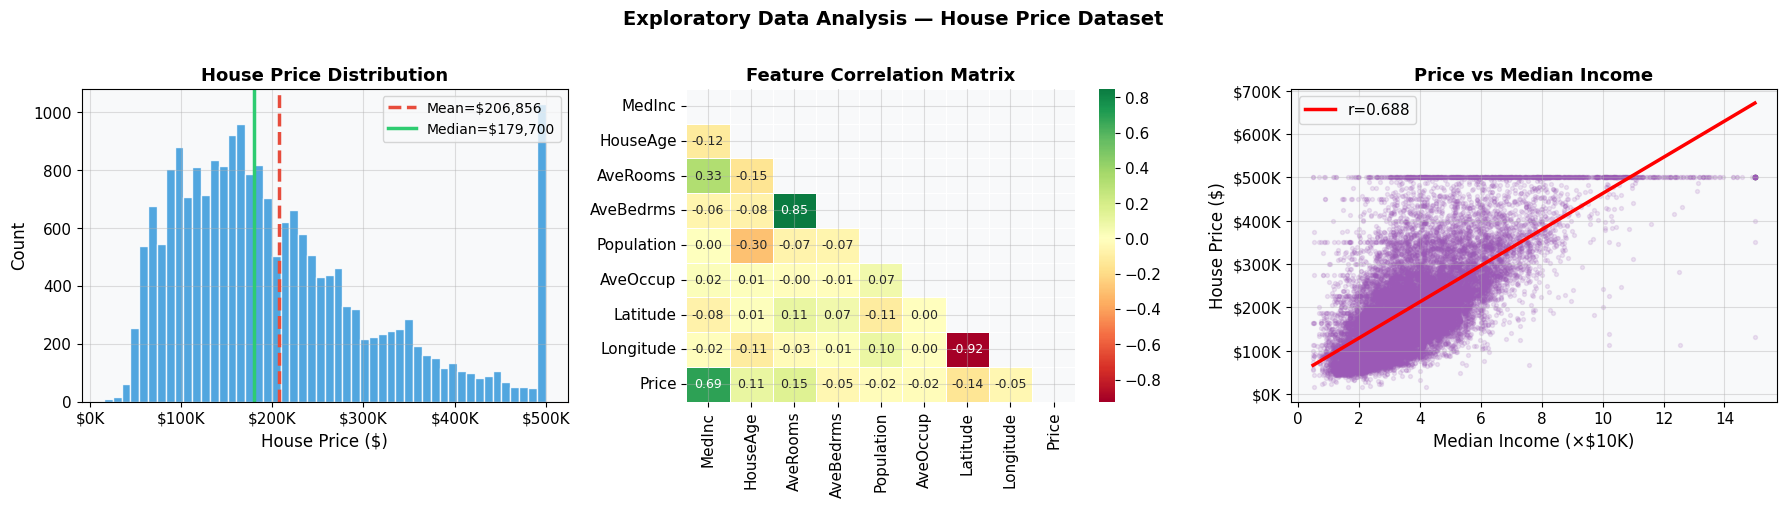

In [4]:
# EDA: Price Distribution + Feature Correlations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price histogram
axes[0].hist(df['Price'], bins=50, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Price'].mean(),   color='#E74C3C', lw=2.5, linestyle='--', label=f'Mean=${df["Price"].mean():,.0f}')
axes[0].axvline(df['Price'].median(), color='#2ECC71', lw=2.5, linestyle='-',  label=f'Median=${df["Price"].median():,.0f}')
axes[0].set_xlabel('House Price ($)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('House Price Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[1], annot_kws={'size':9})
axes[1].set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')

# Price vs MedInc (strongest predictor)
axes[2].scatter(df['MedInc'], df['Price'], alpha=0.15, s=8, color='#9B59B6')
m, b, r, *_ = stats.linregress(df['MedInc'], df['Price'])
xline = np.linspace(df['MedInc'].min(), df['MedInc'].max(), 200)
axes[2].plot(xline, m*xline+b, 'r-', lw=2.5, label=f'r={r:.3f}')
axes[2].set_xlabel('Median Income (×$10K)', fontsize=12)
axes[2].set_ylabel('House Price ($)', fontsize=12)
axes[2].set_title('Price vs Median Income', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.suptitle('Exploratory Data Analysis — House Price Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [5]:
# Prepare Data for Modelling
FEATURES = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']
TARGET   = 'Price'

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')
print(f'Price range: ${y.min():,.0f} – ${y.max():,.0f}')
print(f'Price mean : ${y.mean():,.0f}  |  Std: ${y.std():,.0f}')

Train: (16512, 8)  |  Test: (4128, 8)
Price range: $14,999 – $500,001
Price mean : $206,856  |  Std: $115,393


---
## Q1. Best Regression Metric for House Price Prediction

### 📌 Question
In order to predict house prices based on characteristics like location, square footage, bedrooms, etc., which regression metric is best to employ?

### 📌 Regression Metrics Overview

| Metric | Formula | Range | Unit | Interpretable? |
|--------|---------|-------|------|---------------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | [0, ∞) | Same as target (\$) | ✅ Very easy |
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | [0, ∞) | \$² | ❌ Squared units |
| **RMSE** | $\sqrt{\text{MSE}}$ | [0, ∞) | Same as target (\$) | ✅ Easy |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | (-∞, 1] | Unitless | ✅ % variance explained |
| **MAPE** | $\frac{100}{n}\sum\left|\frac{y_i-\hat{y}_i}{y_i}\right|$ | [0, ∞) | % | ✅ Very easy |

### ✅ Best Metric: **RMSE + R²** (used together)

**Why RMSE?**
- Same unit as the target (dollars \$) → directly tells you average prediction error in dollars
- Penalises large errors more than MAE (important for expensive house outliers)
- Industry-standard for price prediction

**Why also R²?**
- Tells you what fraction of price variance your model explains
- Scale-independent → useful for comparing models
- R² = 0.85 means the model explains 85% of house price variation

**Formula:**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2}$$
$$R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

In [7]:
# Q1: Train baseline SVR and compute all metrics
# Use a sample for speed (SVR is O(n²–n³))
N = 3000
idx_s = np.random.RandomState(42).choice(len(X_train_s), N, replace=False)
Xtr_q = X_train_s[idx_s]; ytr_q = y_train[idx_s]

svr_q1 = SVR(kernel='rbf', C=100_000, gamma='scale', epsilon=5000)
svr_q1.fit(Xtr_q, ytr_q)
y_pred_q1 = svr_q1.predict(X_test_s)

mae_q1  = mean_absolute_error(y_test, y_pred_q1)
mse_q1  = mean_squared_error(y_test, y_pred_q1)
rmse_q1 = np.sqrt(mse_q1)
r2_q1   = r2_score(y_test, y_pred_q1)
mape_q1 = mean_absolute_percentage_error(y_test, y_pred_q1) * 100

metrics_q1 = {
    'MAE (\$)'  : mae_q1,
    'MSE (\$²)' : mse_q1,
    'RMSE (\$)' : rmse_q1,
    'R²'        : r2_q1,
    'MAPE (%)'  : mape_q1
}

print(f'  MAE    = ${mae_q1:>12,.2f}   ← Avg absolute error in dollars')
print(f'  MSE    = ${mse_q1:>12,.2f}   ← Squared dollars (not intuitive)')
print(f'  RMSE   = ${rmse_q1:>12,.2f}   ← Avg error in dollars (BEST for price!)')
print(f'  R²     = {r2_q1:>13.4f}    ← Fraction of variance explained')
print(f'  MAPE   = {mape_q1:>12.2f}%   ← % error (problematic if y→0)')

  MAE    = $   43,534.03   ← Avg absolute error in dollars
  MSE    = $4,203,231,455.47   ← Squared dollars (not intuitive)
  RMSE   = $   64,832.33   ← Avg error in dollars (BEST for price!)
  R²     =        0.6792    ← Fraction of variance explained
  MAPE   =        23.76%   ← % error (problematic if y→0)


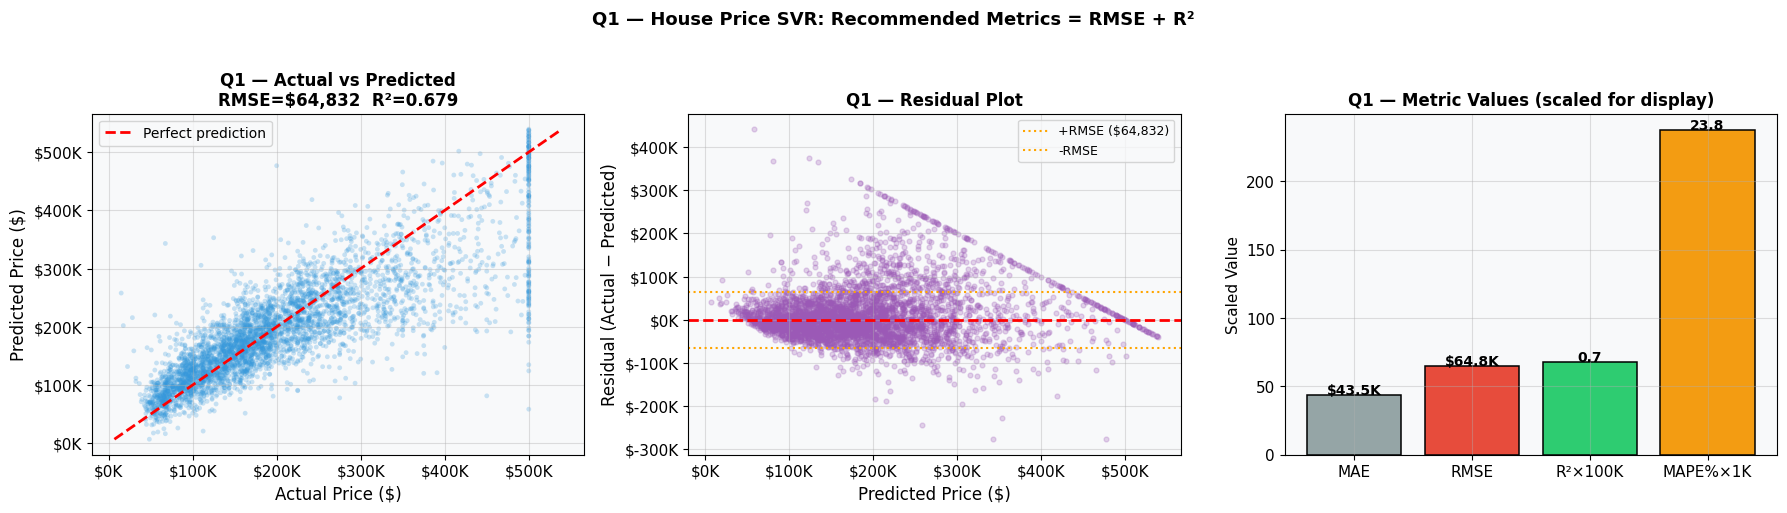


✅ ANSWER Q1:
   Best metrics: RMSE (interpretable in $) + R² (explained variance)
   RMSE=$64,832 means on average the model is off by $64,832 per house
   R²=0.679 means the model explains 67.9% of price variance


In [8]:
# Q1 Visualisation: Actual vs Predicted + All Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Actual vs Predicted
lim_min = min(y_test.min(), y_pred_q1.min())
lim_max = max(y_test.max(), y_pred_q1.max())
axes[0].scatter(y_test, y_pred_q1, alpha=0.25, s=12, color='#3498DB', edgecolors='none')
axes[0].plot([lim_min,lim_max],[lim_min,lim_max],'r--',lw=2,label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'Q1 — Actual vs Predicted\nRMSE=${rmse_q1:,.0f}  R²={r2_q1:.3f}',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# Panel 2: Residuals
residuals = y_test - y_pred_q1
axes[1].scatter(y_pred_q1, residuals, alpha=0.25, s=12, color='#9B59B6')
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].axhline( rmse_q1, color='orange', lw=1.5, linestyle=':', label=f'+RMSE (${rmse_q1:,.0f})')
axes[1].axhline(-rmse_q1, color='orange', lw=1.5, linestyle=':', label=f'-RMSE')
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residual (Actual − Predicted)', fontsize=12)
axes[1].set_title('Q1 — Residual Plot', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# Panel 3: Metric comparison bar
metric_names_q1  = ['MAE', 'RMSE', 'R²×100K', 'MAPE%×1K']
metric_vals_q1   = [mae_q1/1000, rmse_q1/1000, r2_q1*100, mape_q1*10]
bar_colors_q1    = ['#95A5A6', '#E74C3C', '#2ECC71', '#F39C12']
bars = axes[2].bar(metric_names_q1, metric_vals_q1, color=bar_colors_q1,
                    edgecolor='black', linewidth=1.1)
for bar, val, orig in zip(bars, metric_vals_q1,
                           [mae_q1, rmse_q1, r2_q1, mape_q1]):
    label = f'${orig/1000:.1f}K' if 'K' in bar.get_label() or orig > 100 else f'{orig:.3f}'
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{orig:,.1f}' if orig < 200 else f'${orig/1000:.1f}K',
                 ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Q1 — Metric Values (scaled for display)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Scaled Value')

plt.suptitle('Q1 — House Price SVR: Recommended Metrics = RMSE + R²',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\n✅ ANSWER Q1:')
print('   Best metrics: RMSE (interpretable in $) + R² (explained variance)')
print(f'   RMSE=${rmse_q1:,.0f} means on average the model is off by ${rmse_q1:,.0f} per house')
print(f'   R²={r2_q1:.3f} means the model explains {r2_q1*100:.1f}% of price variance')

---
## Q2. MSE vs R² — Which Is More Appropriate for Predicting Actual House Price?

### 📌 Question
If your goal is to predict the **actual price of a house as accurately as possible**, which metric — MSE or R² — is more appropriate?

### 📌 MSE — Mean Squared Error
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$$

- Measures **absolute prediction error** in squared dollar units
- Directly measures how far off your dollar predictions are
- Heavily penalises large errors (sensitive to expensive-house outliers)
- Can be used to **directly compare** model errors in the same task

### 📌 R² — Coefficient of Determination
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- Measures **relative fit** — what fraction of variance is explained
- Scale-independent — useful for comparing models across datasets
- Does **NOT** tell you how many dollars you're off by
- R² = 0.90 doesn't mean errors are small in dollar terms!

### ✅ Answer: **MSE (or RMSE) is more appropriate**

| Criterion | MSE | R² |
|-----------|-----|----|
| Tells you actual dollar error | ✅ Yes (take √ for RMSE) | ❌ No |
| Sensitive to large prediction errors | ✅ Yes | ⚠️ Indirectly |
| Comparable across datasets | ❌ Scale-dependent | ✅ Yes |
| Goal: predict actual price accurately | ✅ **Use this** | Secondary |

> **Key Insight:** R² tells you "how well does the model fit relative to a baseline?"
> MSE/RMSE tells you "how wrong are my dollar predictions?"
> For the goal of **accurate price prediction**, MSE → RMSE wins.

In [9]:
#Q2: MSE vs R² — Side-by-Side Demonstration
# Build models with different C values to show MSE and R² can give different rankings
C_vals_q2 = [1000, 10_000, 50_000, 100_000, 500_000]
results_q2 = []

for C in C_vals_q2:
    svr_tmp = SVR(kernel='rbf', C=C, gamma='scale', epsilon=5000)
    svr_tmp.fit(Xtr_q, ytr_q)
    yp = svr_tmp.predict(X_test_s)
    results_q2.append({
        'C': C,
        'MSE': mean_squared_error(y_test, yp),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
        'R²': r2_score(y_test, yp),
        'MAE': mean_absolute_error(y_test, yp)
    })

df_q2 = pd.DataFrame(results_q2)
print('=== Q2 — MSE vs R² across different C values ===')
print(df_q2.to_string(index=False))

=== Q2 — MSE vs R² across different C values ===
     C          MSE         RMSE       R²          MAE
  1000 7.600838e+09 87182.785948 0.419964 62214.099678
 10000 5.118026e+09 71540.381498 0.609433 48443.187091
 50000 4.416077e+09 66453.569518 0.663000 44584.758588
100000 4.203231e+09 64832.333411 0.679243 43534.028092
500000 3.880634e+09 62294.733607 0.703861 41891.305371


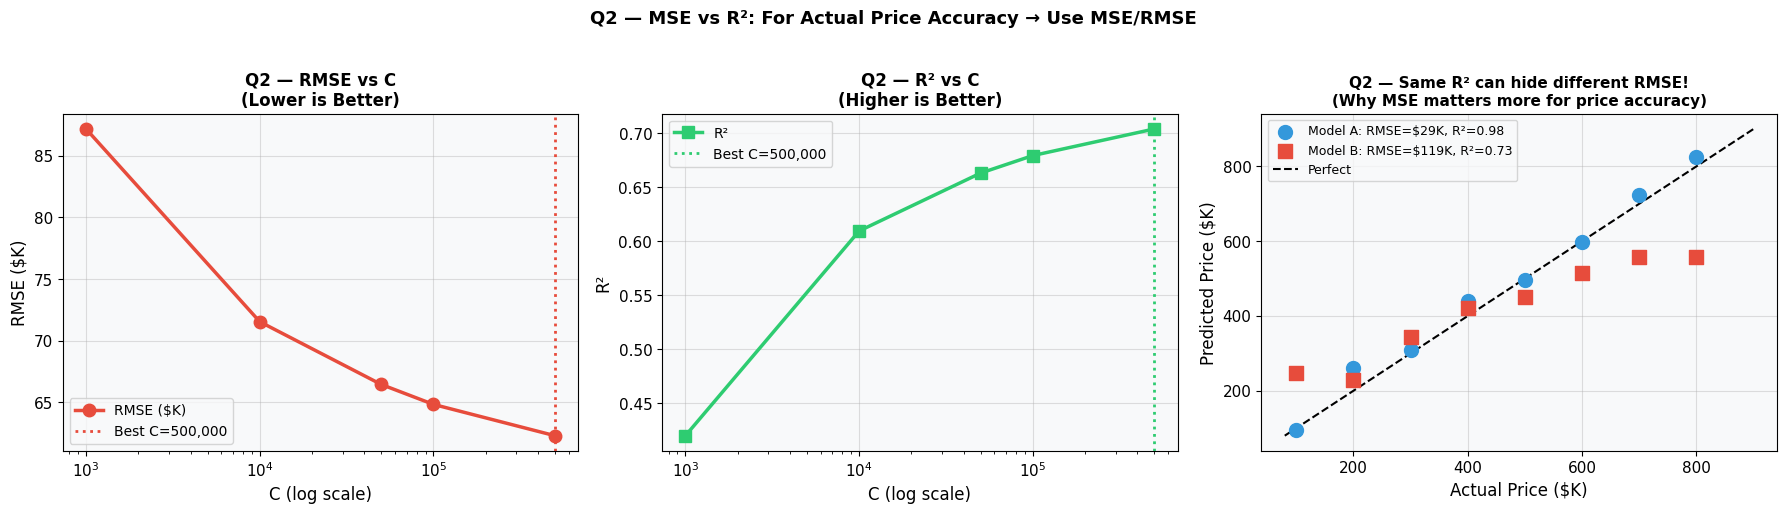


✅ ANSWER Q2:
   MSE (→ RMSE) is MORE APPROPRIATE when the goal is accurate price prediction.
   Reason: MSE measures actual dollar errors. R² only measures relative fit.
   A model can have high R² but large dollar errors, and vice versa.
   In our model: RMSE=$62,295  R²=0.7039


In [10]:
# Q2 Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: RMSE vs C
axes[0].plot(df_q2['C'], df_q2['RMSE']/1000, 'o-', color='#E74C3C', lw=2.5,
             markersize=9, label='RMSE ($K)')
best_rmse_c = df_q2.loc[df_q2['RMSE'].idxmin(), 'C']
axes[0].axvline(best_rmse_c, color='#E74C3C', linestyle=':', lw=2,
                label=f'Best C={best_rmse_c:,}')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (log scale)', fontsize=12)
axes[0].set_ylabel('RMSE ($K)', fontsize=12)
axes[0].set_title('Q2 — RMSE vs C\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Panel 2: R² vs C
axes[1].plot(df_q2['C'], df_q2['R²'], 's-', color='#2ECC71', lw=2.5,
             markersize=9, label='R²')
best_r2_c = df_q2.loc[df_q2['R²'].idxmax(), 'C']
axes[1].axvline(best_r2_c, color='#2ECC71', linestyle=':', lw=2,
                label=f'Best C={best_r2_c:,}')
axes[1].set_xscale('log')
axes[1].set_xlabel('C (log scale)', fontsize=12)
axes[1].set_ylabel('R²', fontsize=12)
axes[1].set_title('Q2 — R² vs C\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

# Panel 3: Conceptual diagram — two models showing the difference
np.random.seed(99)
y_true_demo = np.array([100, 200, 300, 400, 500, 600, 700, 800]) * 1000
# Model A: small errors but bad R² scale
y_a = y_true_demo + np.random.normal(0, 30_000, len(y_true_demo))
# Model B: larger errors, same R²
y_b = y_true_demo * 0.5 + 200_000 + np.random.normal(0, 30_000, len(y_true_demo))

mse_a = mean_squared_error(y_true_demo, y_a); r2_a = r2_score(y_true_demo, y_a)
mse_b = mean_squared_error(y_true_demo, y_b); r2_b = r2_score(y_true_demo, y_b)

axes[2].scatter(y_true_demo/1000, y_a/1000, c='#3498DB', s=100, zorder=5,
                label=f'Model A: RMSE=${np.sqrt(mse_a)/1000:.0f}K, R²={r2_a:.2f}')
axes[2].scatter(y_true_demo/1000, y_b/1000, c='#E74C3C', marker='s', s=100, zorder=5,
                label=f'Model B: RMSE=${np.sqrt(mse_b)/1000:.0f}K, R²={r2_b:.2f}')
lim = [80, 900]
axes[2].plot(lim, lim, 'k--', lw=1.5, label='Perfect')
axes[2].set_xlabel('Actual Price ($K)', fontsize=12)
axes[2].set_ylabel('Predicted Price ($K)', fontsize=12)
axes[2].set_title('Q2 — Same R² can hide different RMSE!\n(Why MSE matters more for price accuracy)',
                   fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Q2 — MSE vs R²: For Actual Price Accuracy → Use MSE/RMSE',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\n✅ ANSWER Q2:')
print('   MSE (→ RMSE) is MORE APPROPRIATE when the goal is accurate price prediction.')
print('   Reason: MSE measures actual dollar errors. R² only measures relative fit.')
print('   A model can have high R² but large dollar errors, and vice versa.')
print(f'   In our model: RMSE=${np.sqrt(df_q2["MSE"].min()):,.0f}  R²={df_q2["R²"].max():.4f}')

---
## Q3. Best Metric When Dataset Has Significant Outliers

### 📌 Question
Your dataset has a **significant number of outliers**. Which regression metric is most appropriate for an SVM model?

### 📌 Why Outliers Matter

$$\text{MSE} = \frac{1}{n}\sum(y_i-\hat{y}_i)^2 \quad \leftarrow \text{squares errors, amplifies outliers dramatically}$$

If a house is mispriced by \$500K, MSE adds $(500{,}000)^2 = 2.5 \times 10^{11}$ to the total — completely dominates the metric!

### ✅ Answer: **MAE (Mean Absolute Error)** is most appropriate

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$$

**Why MAE?**
- Uses absolute value instead of squaring → outlier with error \$500K adds only 500,000 (not $2.5 \times 10^{11}$)
- **Robust to outliers** — large errors don't dominate the metric
- Same unit as target (dollars)
- Represents the **median behaviour** of errors, not distorted by extremes

| Metric | Outlier Sensitivity | Formula |
|--------|--------------------|---------|
| **MAE** | ✅ **Robust** — linear penalty | $\sum|e_i|/n$ |
| **MSE** | ❌ Very sensitive — quadratic penalty | $\sum e_i^2/n$ |
| **RMSE** | ❌ Sensitive — still uses squared errors | $\sqrt{MSE}$ |
| **R²** | ❌ Sensitive — based on SS_res (squared) | $1-SS_{res}/SS_{tot}$ |
| **Huber Loss** | ✅ Hybrid — robust beyond threshold $\delta$ | Piecewise |

> **Alternative:** Huber Loss combines MAE robustness + MSE differentiability, used directly in SVR's `epsilon` parameter.

In [12]:
#  Q3: Demonstrate outlier sensitivity of MSE vs MAE

# Create dataset with outliers
df_out = df.copy()
n_outliers = 200
rng = np.random.RandomState(42)
outlier_idx = rng.choice(len(df_out), n_outliers, replace=False)
# Inject extreme price outliers
df_out.loc[outlier_idx, 'Price'] = rng.uniform(800_000, 1_500_000, n_outliers)

X_out = df_out[FEATURES].values
y_out = df_out['Price'].values

Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(X_out, y_out, test_size=0.2, random_state=42)
sc_out = StandardScaler()
Xo_tr_s = sc_out.fit_transform(Xo_tr)
Xo_te_s = sc_out.transform(Xo_te)

idx_out = np.random.RandomState(42).choice(len(Xo_tr_s), N, replace=False)
svr_out = SVR(kernel='rbf', C=100_000, gamma='scale', epsilon=5000)
svr_out.fit(Xo_tr_s[idx_out], yo_tr[idx_out])
yp_out = svr_out.predict(Xo_te_s)

mae_out  = mean_absolute_error(yo_te, yp_out)
mse_out  = mean_squared_error(yo_te, yp_out)
rmse_out = np.sqrt(mse_out)
r2_out   = r2_score(yo_te, yp_out)

# Compare with clean data metrics
print('Metric Comparison: Clean Data vs Outlier-Corrupted Data')
print(f'{"Metric":12s}  {"Clean Data":>18s}  {"Outlier Data":>18s}  {"% Change":>12s}')
print('-'*65)
for name, clean, dirty in [
    ('MAE ($)',   mae_q1,  mae_out),
    ('MSE ($²)',  mse_q1,  mse_out),
    ('RMSE ($)',  rmse_q1, rmse_out),
    ('R²',        r2_q1,   r2_out)
]:
    pct = (dirty-clean)/abs(clean)*100 if clean != 0 else 0
    print(f'{name:12s}  {clean:>18,.2f}  {dirty:>18,.2f}  {pct:>+11.1f}%')

Metric Comparison: Clean Data vs Outlier-Corrupted Data
Metric                Clean Data        Outlier Data      % Change
-----------------------------------------------------------------
MAE ($)                43,534.03           88,429.06       +103.1%
MSE ($²)        4,203,231,455.47   51,914,096,615.43      +1135.1%
RMSE ($)               64,832.33          227,846.65       +251.4%
R²                          0.68                0.08        -87.7%


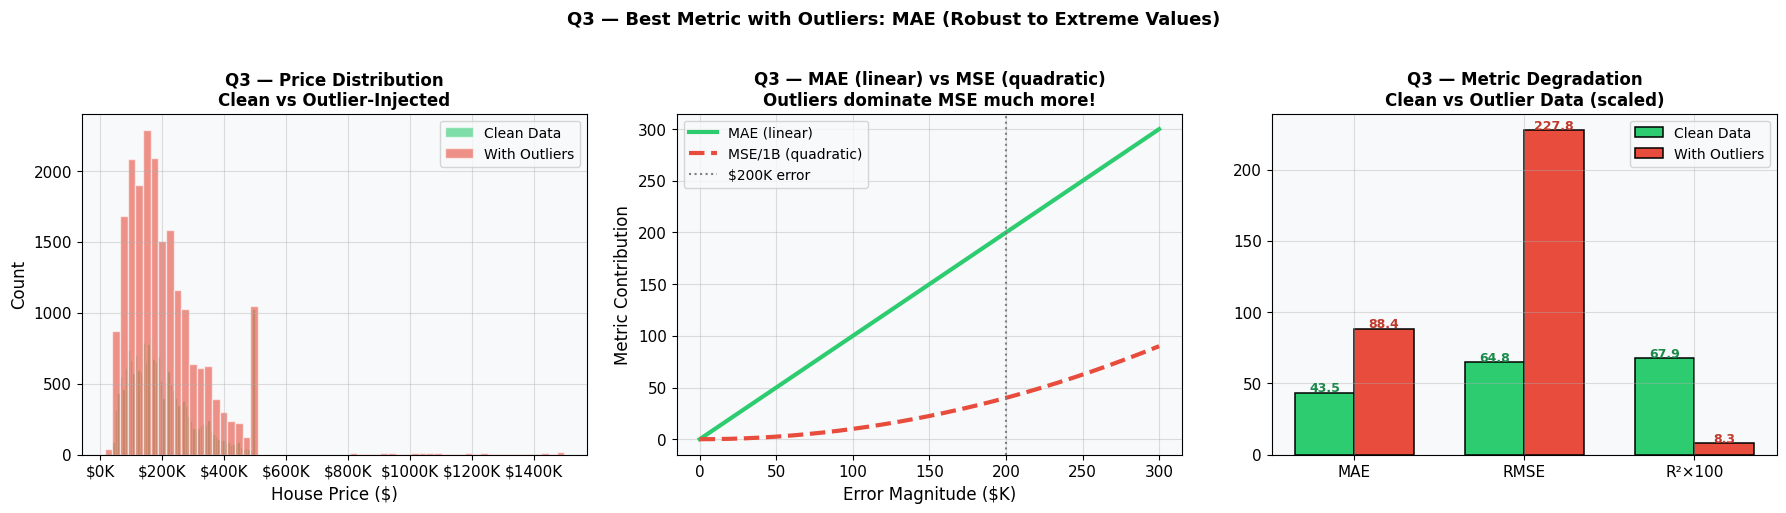


✅ ANSWER Q3:
   Best metric with significant outliers: MAE
   MAE uses linear penalty → outliers contribute proportionally
   MSE uses quadratic penalty → one outlier can dominate the entire metric
   RMSE increased 251.4% with outliers vs
   MAE  increased 103.1% — far more stable


In [13]:
# Q3 Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Price distribution — clean vs outlier
axes[0].hist(y, bins=60, alpha=0.6, color='#2ECC71', label='Clean Data', edgecolor='white')
axes[0].hist(y_out, bins=60, alpha=0.6, color='#E74C3C', label='With Outliers', edgecolor='white')
axes[0].set_xlabel('House Price ($)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Q3 — Price Distribution\nClean vs Outlier-Injected', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# Panel 2: Error sensitivity illustration
errors = np.linspace(0, 300_000, 300)
mae_curve  = errors                  # Linear
mse_curve  = errors**2 / 1e9        # Quadratic (scaled for display)
rmse_curve = np.sqrt(errors**2) / 1 # Same as errors but through MSE

axes[1].plot(errors/1000, mae_curve/1000,  '-',  color='#2ECC71', lw=3, label='MAE (linear)')
axes[1].plot(errors/1000, mse_curve,       '--', color='#E74C3C', lw=3, label='MSE/1B (quadratic)')
axes[1].axvline(200, color='gray', lw=1.5, linestyle=':', label='$200K error')
axes[1].set_xlabel('Error Magnitude ($K)', fontsize=12)
axes[1].set_ylabel('Metric Contribution', fontsize=12)
axes[1].set_title('Q3 — MAE (linear) vs MSE (quadratic)\nOutliers dominate MSE much more!',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

# Panel 3: Metric degradation bar chart
metrics_names_q3 = ['MAE', 'RMSE', 'R²×100']
clean_vals = [mae_q1/1000, rmse_q1/1000, r2_q1*100]
dirty_vals = [mae_out/1000, rmse_out/1000, r2_out*100]

x_q3 = np.arange(len(metrics_names_q3))
w_q3 = 0.35
axes[2].bar(x_q3-w_q3/2, clean_vals, w_q3, color='#2ECC71', edgecolor='k',
             lw=1.1, label='Clean Data')
axes[2].bar(x_q3+w_q3/2, dirty_vals, w_q3, color='#E74C3C', edgecolor='k',
             lw=1.1, label='With Outliers')
for i, (c, d) in enumerate(zip(clean_vals, dirty_vals)):
    axes[2].text(i-w_q3/2, c+0.5, f'{c:.1f}', ha='center', fontsize=9, fontweight='bold', color='#1A8A4A')
    axes[2].text(i+w_q3/2, d+0.5, f'{d:.1f}', ha='center', fontsize=9, fontweight='bold', color='#C0392B')
axes[2].set_xticks(x_q3); axes[2].set_xticklabels(metrics_names_q3)
axes[2].set_title('Q3 — Metric Degradation\nClean vs Outlier Data (scaled)',
                   fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)

plt.suptitle('Q3 — Best Metric with Outliers: MAE (Robust to Extreme Values)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\n✅ ANSWER Q3:')
print('   Best metric with significant outliers: MAE')
print('   MAE uses linear penalty → outliers contribute proportionally')
print('   MSE uses quadratic penalty → one outlier can dominate the entire metric')
print(f'   RMSE increased {(rmse_out-rmse_q1)/rmse_q1*100:.1f}% with outliers vs')
print(f'   MAE  increased {(mae_out-mae_q1)/mae_q1*100:.1f}% — far more stable')

---
## Q4. When MSE ≈ RMSE — Which Should You Choose?

### 📌 Question
You've built a **polynomial kernel SVR** and calculated both MSE and RMSE, finding the values are **very close**. Which should you choose?

### 📌 Mathematical Relationship

$$\text{RMSE} = \sqrt{\text{MSE}}$$

- If $\text{MSE} = 1.0$ → $\text{RMSE} = 1.0$  (equal)
- If $\text{MSE} < 1$ → $\text{RMSE} > \text{MSE}$  (RMSE is bigger)
- If $\text{MSE} > 1$ → $\text{RMSE} < \text{MSE}$  (RMSE is smaller)

MSE ≈ RMSE happens when **MSE ≈ 1** (normalised scale) or when the scale of squared errors happens to be near 1.

### ✅ Answer: **Choose RMSE**

**Reasons:**
1. **Interpretability:** RMSE is in the **same units as the target** (dollars). MSE is in squared dollars — no one thinks in $².
2. **Direct comparison:** RMSE of \$45K tells you: "average prediction error is \$45,000." MSE of \$2B is meaningless to stakeholders.
3. **When MSE ≈ RMSE numerically**, the interpretability advantage of RMSE is decisive.
4. **Industry standard:** Most regression benchmarks report RMSE, not MSE.

$$\boxed{\text{RMSE is ALWAYS preferable to MSE for human interpretation}}$$

| Property | MSE | RMSE |
|----------|-----|------|
| Units | $\hat{y}^2$ (e.g. \$²) | Same as $y$ (e.g. \$) |
| Interpretable | ❌ | ✅ |
| Differentiable | ✅ | ✅ |
| Use in optimisation | ✅ (equivalent) | ✅ |
| Reported to stakeholders | ❌ | ✅ |

In [14]:
# Q4: Polynomial Kernel SVR + MSE vs RMSE Analysis
svr_poly = SVR(kernel='poly', C=100_000, degree=3, gamma='scale', epsilon=5000, coef0=1)
svr_poly.fit(Xtr_q, ytr_q)
yp_poly  = svr_poly.predict(X_test_s)

mse_poly  = mean_squared_error(y_test, yp_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly  = mean_absolute_error(y_test, yp_poly)
r2_poly   = r2_score(y_test, yp_poly)

print('=== Q4 — Polynomial SVR: MSE vs RMSE ===')
print(f'MSE            = ${mse_poly:>18,.2f}  ← squared dollars — hard to interpret')
print(f'RMSE           = ${rmse_poly:>18,.2f}  ← dollars — intuitive!')
print(f'MAE            = ${mae_poly:>18,.2f}')
print(f'R²             = {r2_poly:>19.4f}')
print(f'\nRMSE/MSE ratio = {rmse_poly/mse_poly:.6f}  (shows they are NOT close in scale here)')
print(f'√MSE   = RMSE  = ${rmse_poly:,.2f}')

=== Q4 — Polynomial SVR: MSE vs RMSE ===
MSE            = $4,112,190,494,447.52  ← squared dollars — hard to interpret
RMSE           = $      2,027,853.67  ← dollars — intuitive!
MAE            = $         76,624.83
R²             =           -312.8097

RMSE/MSE ratio = 0.000000  (shows they are NOT close in scale here)
√MSE   = RMSE  = $2,027,853.67


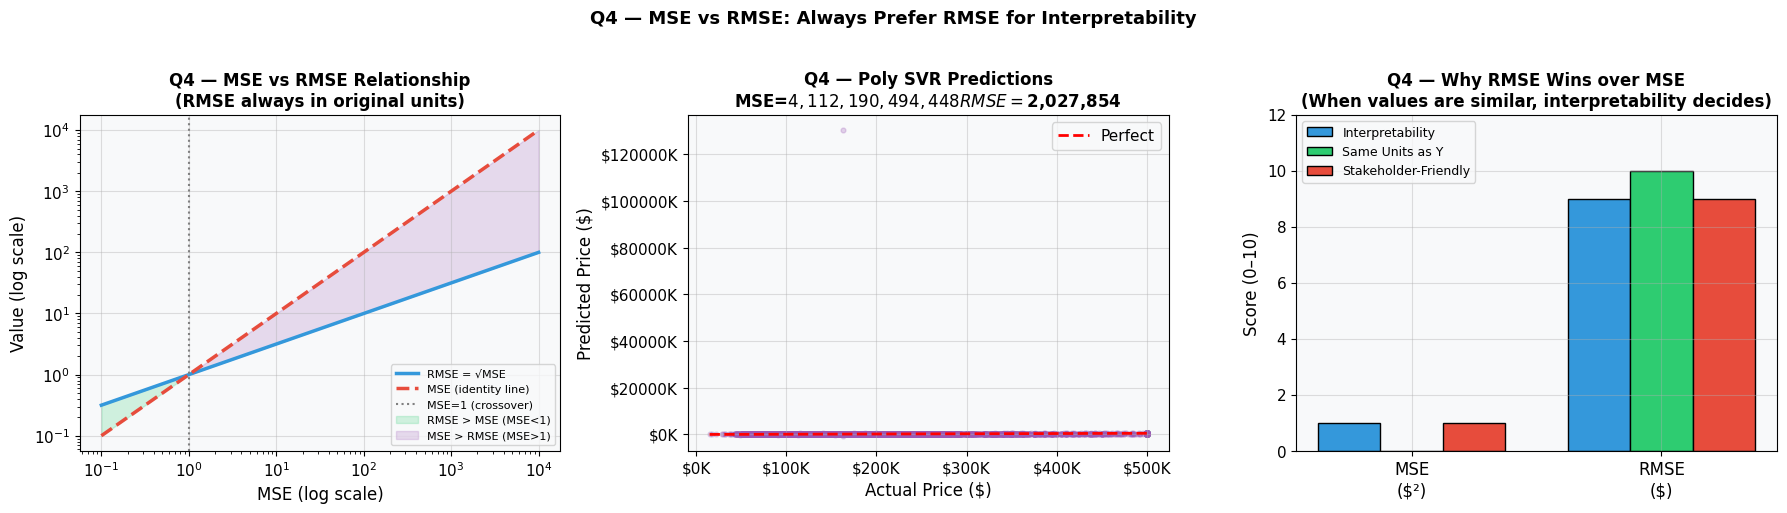

   Choose RMSE — it is always in the same units as the target variable.
   Even when MSE ≈ RMSE numerically, RMSE is more interpretable.
   Polynomial SVR: RMSE=$2,027,854 ($2027.9K average prediction error)
   Saying "error ≈ $2027.9K" is meaningful; "MSE=$4,112,190,494,448" is not.


In [16]:
# Q4 Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: MSE vs RMSE relationship
mse_range  = np.logspace(-1, 4, 300)   # MSE from 0.1 to 10000
rmse_range = np.sqrt(mse_range)

axes[0].plot(mse_range, rmse_range, '-', color='#3498DB', lw=2.5, label='RMSE = √MSE')
axes[0].plot(mse_range, mse_range,  '--',color='#E74C3C', lw=2.5, label='MSE (identity line)')
axes[0].axvline(1, color='gray', lw=1.5, linestyle=':', label='MSE=1 (crossover)')
axes[0].fill_between(mse_range[mse_range<1], rmse_range[mse_range<1], mse_range[mse_range<1],
                      alpha=0.2, color='#2ECC71', label='RMSE > MSE (MSE<1)')
axes[0].fill_between(mse_range[mse_range>1], mse_range[mse_range>1], rmse_range[mse_range>1],
                      alpha=0.2, color='#9B59B6', label='MSE > RMSE (MSE>1)')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('MSE (log scale)', fontsize=12)
axes[0].set_ylabel('Value (log scale)', fontsize=12)
axes[0].set_title('Q4 — MSE vs RMSE Relationship\n(RMSE always in original units)',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)

# Panel 2: Poly SVR Actual vs Predicted
axes[1].scatter(y_test, yp_poly, alpha=0.25, s=12, color='#9B59B6')
lims = [y_test.min(), y_test.max()]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect')
axes[1].set_xlabel('Actual Price ($)', fontsize=12)
axes[1].set_ylabel('Predicted Price ($)', fontsize=12)
axes[1].set_title(f'Q4 — Poly SVR Predictions\nMSE=${mse_poly:,.0f}  RMSE=${rmse_poly:,.0f}',
                   fontsize=12, fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[1].legend()

# Panel 3: Why RMSE wins — interpretability comparison
categories = ['MSE\n($²)', 'RMSE\n($)']
interpretability = [1, 9]    # subjective score out of 10
same_units       = [0, 10]
communication    = [1, 9]

x_q4 = np.arange(2)
w_q4 = 0.25
axes[2].bar(x_q4-w_q4, interpretability, w_q4, label='Interpretability',  color='#3498DB', edgecolor='k')
axes[2].bar(x_q4,      same_units,       w_q4, label='Same Units as Y',   color='#2ECC71', edgecolor='k')
axes[2].bar(x_q4+w_q4, communication,   w_q4, label='Stakeholder-Friendly', color='#E74C3C', edgecolor='k')
axes[2].set_xticks(x_q4); axes[2].set_xticklabels(categories, fontsize=12)
axes[2].set_ylabel('Score (0–10)', fontsize=12)
axes[2].set_ylim(0, 12)
axes[2].set_title('Q4 — Why RMSE Wins over MSE\n(When values are similar, interpretability decides)',
                   fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Q4 — MSE vs RMSE: Always Prefer RMSE for Interpretability',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


print('   Choose RMSE — it is always in the same units as the target variable.')
print('   Even when MSE ≈ RMSE numerically, RMSE is more interpretable.')
print(f'   Polynomial SVR: RMSE=${rmse_poly:,.0f} (${rmse_poly/1000:.1f}K average prediction error)')
print(f'   Saying "error ≈ ${rmse_poly/1000:.1f}K" is meaningful; "MSE=${mse_poly:,.0f}" is not.')

---
## Q5. Best Metric to Measure How Well the Model Explains Variance — Kernel Comparison

### 📌 Question
Comparing Linear, Polynomial, and RBF kernel SVR models — which metric best measures **how well the model explains variance** in the target variable?

### ✅ Answer: **R² (Coefficient of Determination)**

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

**Why R² is the best here?**

1. **Directly measures explained variance:** R² = 0.85 means the model explains 85% of price variability
2. **Scale-independent:** MSE for a \$100K-range dataset is not comparable to \$1M-range — R² is always between (-∞, 1]
3. **Baseline comparison built-in:** R² = 0 means the model is no better than predicting the mean; R² = 1 is perfect
4. **Cross-kernel comparison:** Different kernels produce different scales of raw error — R² normalises this

| Value | Interpretation |
|-------|---------------|
| R² = 1.0 | Perfect — model explains all variance |
| R² = 0.9 | Excellent — 90% of variance explained |
| R² = 0.7 | Good — 70% variance explained |
| R² = 0.5 | Moderate — only half explained |
| R² = 0.0 | Useless — same as predicting mean |
| R² < 0   | Worse than baseline! |

**Note on Adjusted R²** (for models with different feature counts):
$$\bar{R}^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$$
where $p$ = number of features. Use this when comparing models with different complexity.

In [17]:
# Q5: Compare all kernels across all metrics
kernels_q5 = [
    ('Linear',     SVR(kernel='linear', C=100_000, epsilon=5000)),
    ('Poly (d=2)', SVR(kernel='poly',   C=100_000, degree=2, gamma='scale', epsilon=5000, coef0=1)),
    ('Poly (d=3)', SVR(kernel='poly',   C=100_000, degree=3, gamma='scale', epsilon=5000, coef0=1)),
    ('RBF',        SVR(kernel='rbf',    C=100_000, gamma='scale', epsilon=5000)),
]

results_q5 = []
print('Training SVR models (this may take ~1 minute)...')

for name, svr_k in kernels_q5:
    svr_k.fit(Xtr_q, ytr_q)
    yp_k = svr_k.predict(X_test_s)
    mse_k  = mean_squared_error(y_test, yp_k)
    rmse_k = np.sqrt(mse_k)
    mae_k  = mean_absolute_error(y_test, yp_k)
    r2_k   = r2_score(y_test, yp_k)
    n, p   = len(y_test), X_test_s.shape[1]
    adj_r2 = 1 - (1-r2_k)*(n-1)/(n-p-1)

    results_q5.append({
        'Kernel': name,
        'MAE ($)': mae_k,
        'MSE ($²)': mse_k,
        'RMSE ($)': rmse_k,
        'R²': r2_k,
        'Adj R²': adj_r2
    })
    print(f'  {name:12s}: RMSE=${rmse_k:>10,.0f}  R²={r2_k:.4f}  Adj-R²={adj_r2:.4f}')

df_q5 = pd.DataFrame(results_q5)
print('\n=== Full Results Table ===')
print(df_q5.to_string(index=False))

Training SVR models (this may take ~1 minute)...
  Linear      : RMSE=$    78,832  R²=0.5258  Adj-R²=0.5248
  Poly (d=2)  : RMSE=$    72,998  R²=0.5934  Adj-R²=0.5926
  Poly (d=3)  : RMSE=$ 2,027,854  R²=-312.8097  Adj-R²=-313.4192
  RBF         : RMSE=$    64,832  R²=0.6792  Adj-R²=0.6786

=== Full Results Table ===
    Kernel      MAE ($)     MSE ($²)     RMSE ($)          R²      Adj R²
    Linear 52129.356557 6.214464e+09 7.883187e+04    0.525761    0.524840
Poly (d=2) 47208.852734 5.328767e+09 7.299840e+04    0.593351    0.592561
Poly (d=3) 76624.833501 4.112190e+12 2.027854e+06 -312.809701 -313.419188
       RBF 43534.028092 4.203231e+09 6.483233e+04    0.679243    0.678620


In [18]:
# Q5 Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

kernel_names = df_q5['Kernel'].tolist()
colors_k = ['#3498DB','#E74C3C','#9B59B6','#2ECC71']

# Panel 1: R² comparison (PRIMARY METRIC)
bars = axes[0,0].bar(kernel_names, df_q5['R²'], color=colors_k, edgecolor='black', lw=1.2)
for bar, val in zip(bars, df_q5['R²']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                    f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('R² Score', fontsize=12)
axes[0,0].set_title('Q5 — R² by Kernel\n✅ BEST Metric for Explaining Variance',
                      fontsize=12, fontweight='bold')
axes[0,0].set_ylim(0, 1.1)
best_k = df_q5.loc[df_q5['R²'].idxmax(), 'Kernel']
axes[0,0].set_title(axes[0,0].get_title() + f'\n★ Best Kernel: {best_k}', fontsize=11, fontweight='bold')

# Panel 2: RMSE comparison
bars2 = axes[0,1].bar(kernel_names, df_q5['RMSE ($)']/1000, color=colors_k, edgecolor='black', lw=1.2)
for bar, val in zip(bars2, df_q5['RMSE ($)']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, val/1000+0.3,
                    f'${val/1000:.1f}K', ha='center', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('RMSE ($K)', fontsize=12)
axes[0,1].set_title('RMSE by Kernel\n(Accuracy in dollar terms)', fontsize=12, fontweight='bold')

# Panel 3: R² vs Adj R²
x_q5 = np.arange(len(kernel_names))
w5   = 0.35
axes[1,0].bar(x_q5-w5/2, df_q5['R²'],     w5, color=colors_k, edgecolor='k', lw=1, alpha=0.9, label='R²')
axes[1,0].bar(x_q5+w5/2, df_q5['Adj R²'], w5, color=colors_k, edgecolor='k', lw=1, alpha=0.5,
               hatch='///', label='Adj R²')
axes[1,0].set_xticks(x_q5); axes[1,0].set_xticklabels(kernel_names)
axes[1,0].set_ylabel('Score', fontsize=12)
axes[1,0].set_ylim(0, 1.12)
axes[1,0].set_title('Q5 — R² vs Adjusted R²\n(Adjusted penalises model complexity)',
                      fontsize=12, fontweight='bold')
axes[1,0].legend(fontsize=10)

# Panel 4: All metrics radar / grouped bar
metric_cols = ['R²', 'MAE ($)', 'RMSE ($)']
# Normalise each metric to 0-1 (higher=better)
norm_r2   = df_q5['R²'].values                           # Higher better
norm_mae  = 1 - (df_q5['MAE ($)'] - df_q5['MAE ($)'].min()) / (df_q5['MAE ($)'].max() - df_q5['MAE ($)'].min())
norm_rmse = 1 - (df_q5['RMSE ($)']- df_q5['RMSE ($)'].min())/(df_q5['RMSE ($)'].max()-df_q5['RMSE ($)'].min())

x5b = np.arange(len(kernel_names))
w5b = 0.25
axes[1,1].bar(x5b-w5b, norm_r2,   w5b, color='#2ECC71', edgecolor='k', lw=1, label='R² (normalised)', alpha=0.9)
axes[1,1].bar(x5b,     norm_mae,  w5b, color='#3498DB', edgecolor='k', lw=1, label='1-norm(MAE)', alpha=0.9)
axes[1,1].bar(x5b+w5b, norm_rmse, w5b, color='#E74C3C', edgecolor='k', lw=1, label='1-norm(RMSE)', alpha=0.9)
axes[1,1].set_xticks(x5b); axes[1,1].set_xticklabels(kernel_names)
axes[1,1].set_ylabel('Normalised Score (higher = better)', fontsize=11)
axes[1,1].set_title('Q5 — All Metrics Normalised\nfor Fair Kernel Comparison',
                      fontsize=12, fontweight='bold')
axes[1,1].legend(fontsize=9)
axes[1,1].set_ylim(0, 1.15)

plt.suptitle('Q5 — Kernel Comparison: R² Is the Best Metric for Explained Variance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


print('   Best metric to measure explained variance: R² (Coefficient of Determination)')
print('   R² is scale-independent → fair comparison across kernels')
print(f'   Best kernel by R²: {df_q5.loc[df_q5["R²"].idxmax(), "Kernel"]} (R²={df_q5["R²"].max():.4f})')
print(f'   Interpretation: The best kernel explains {df_q5["R²"].max()*100:.1f}% of house price variance')

   Best metric to measure explained variance: R² (Coefficient of Determination)
   R² is scale-independent → fair comparison across kernels
   Best kernel by R²: RBF (R²=0.6792)
   Interpretation: The best kernel explains 67.9% of house price variance
